### Importación de Librerías y Dependencias

En esta primera celda importamos todas las herramientas necesarias para la manipulación de archivos, el procesamiento de los datos musicales y la generación de visualizaciones.

* **`os`** y **`glob`**: Módulos para la gestión de rutas y búsqueda recursiva de archivos dentro de nuestros directorios.
* **`mido`**: Una librería especializada en la lectura y manipulación de archivos **MIDI** (*Musical Instrument Digital Interface*), que nos permitirá acceder a los eventos y mensajes musicales de las pistas.
* **`pandas`** y **`numpy`**: Librerías estándar para el análisis numérico y estructuración eficiente de datos.
* **`matplotlib.pyplot`** y **`seaborn`**: Entornos principales para la creación de gráficas y visualización de datos, indispensables para construir nuestros *Piano Rolls*.

En el siguiente notebook, presentamos el inicio de visualizaciones para nuestros datos del [Maestro](https://magenta.withgoogle.com/datasets/maestro#v300) versión 3.


In [ ]:
import os
from glob import glob
import random
import mido
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Carga de Rutas del Dataset

Aquí definimos la ruta relativa hacia nuestro conjunto de datos. 

Utilizamos la función `glob` para rastrear recursivamente todos los archivos en los subdirectorios. Esto nos devolverá una lista llamada `archivos` que contendrá las rutas completas de todos aquellos archivos con extensión `.midi` o `.mid`, preparándolos para el preprocesamiento.


In [5]:
ruta_base = '../maestro-v3.0.0'
archivos = glob(os.path.join(ruta_base, '**/*.midi*'), recursive=True)

### Generación del Piano y sus datos bidimensionales

En esta celda definimos la función principal `visualizar_midi(ruta_archivo)` que se encarga de decodificar el archivo digital para proyectarlo gráficamente. La lógica detrás de la función se divide en dos pasos clave:

1. **Decodificación Temporal y Filtrado:** 
   El objeto `mido.MidiFile` se recorre mensaje por mensaje. En el protocolo MIDI, el atributo `msg.time` representa el *delta-time* (el tiempo transcurrido desde el último mensaje), por ende, acumulamos esto en la variable `tiempo_total` para tener el tiempo absoluto $t$. Únicamente guardamos las tuplas $(t_i, p_i)$ si el mensaje corresponde a un evento `'note_on'` (tecla presionada) y su velocidad $v > 0$.

2. **Proyección en Plano Cartesiano:**
   Usamos la función `zip(*notas)` para separar nuestras tuplas en dos vectores. Posteriormente generamos un *Scatter Plot* (gráfico de dispersión) donde el Eje $X$ mapea el tiempo transcurrido en segundos, y el Eje $Y$ grafica el tono o frecuencia (*Pitch*). Por último, se le aplican detalles estéticos de sombreado (`alpha`), colores y dimensión de panel para mejorar su interpretación.


In [ ]:
def visualizar_midi(ruta_archivo):
    mid = mido.MidiFile(ruta_archivo)
    notas = []
    tiempo_total = 0
    
    for msg in mid:
        tiempo_total += msg.time
        if msg.type == 'note_on' and msg.velocity > 0:
            notas.append((tiempo_total, msg.note))
    

    tiempos, pitches = zip(*notas)
    
    plt.figure(figsize=(12, 5))
    plt.scatter(tiempos, pitches, s=2, c='royalblue', alpha=0.7)
    plt.title(f"Piano Roll: {os.path.basename(ruta_archivo)}")
    plt.xlabel("Tiempo (segundos)")
    plt.ylabel("Nota MIDI (Pitch)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

### Visualización de Muestras

A través de un ciclo iterativo configurado con las primeras muestras, invocamos nuestra función de visualización para proyectar iterativamente el comportamiento de los primeros 10 archivos de la colección. 

Esto nos permite inspeccionar visualmente la distribución de forma secuencial de las notas en forma de serie de tiempo.


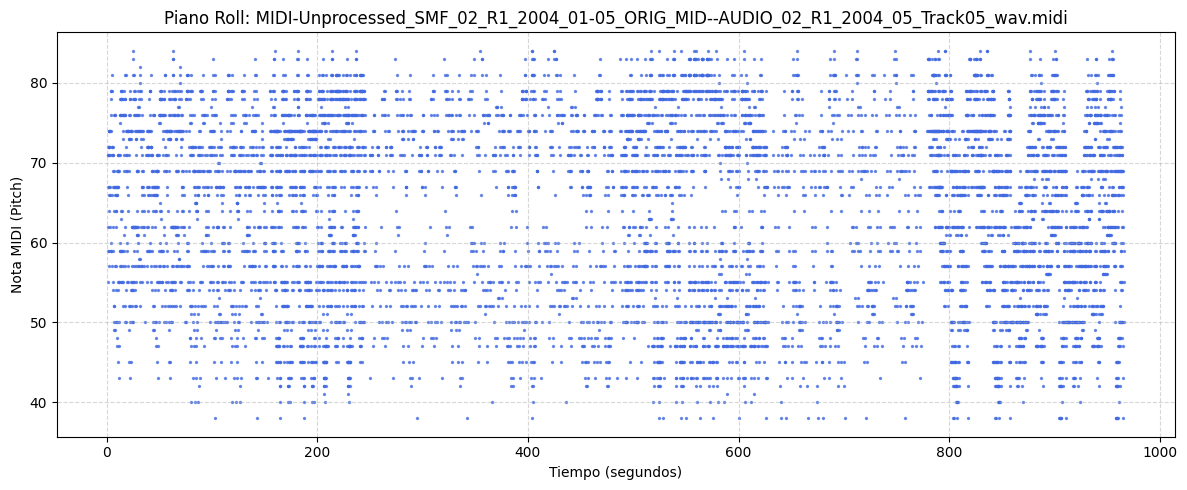

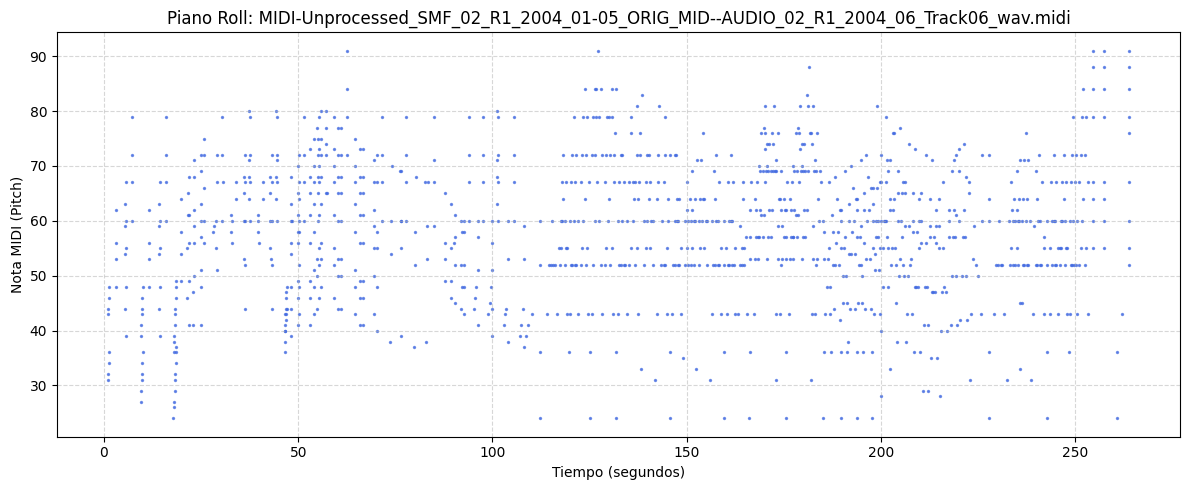

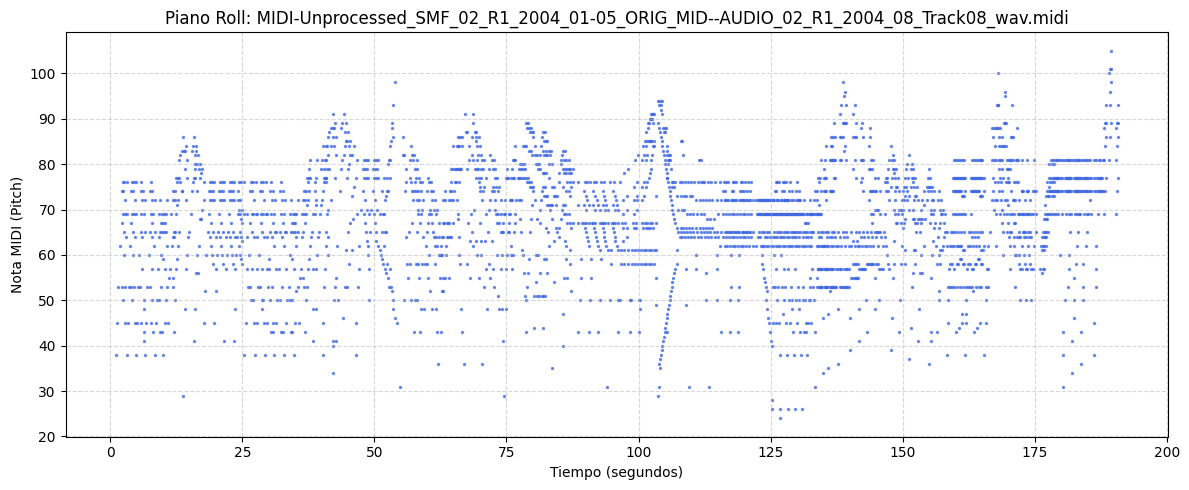

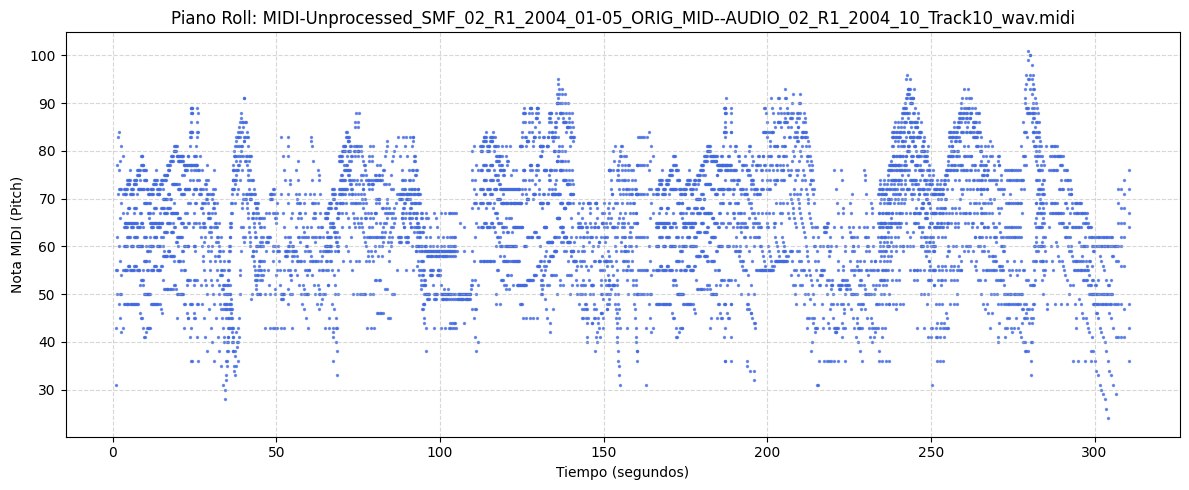

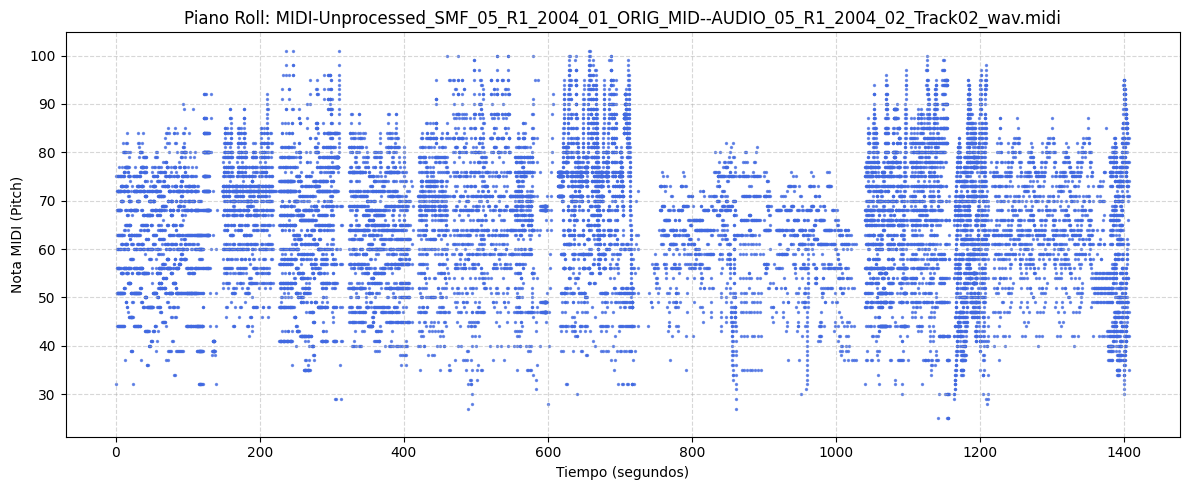

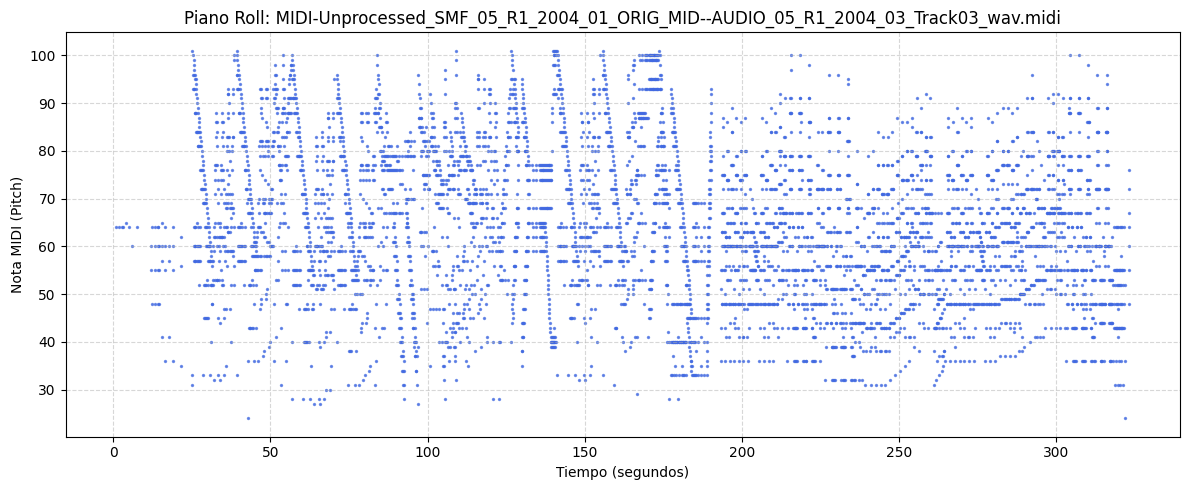

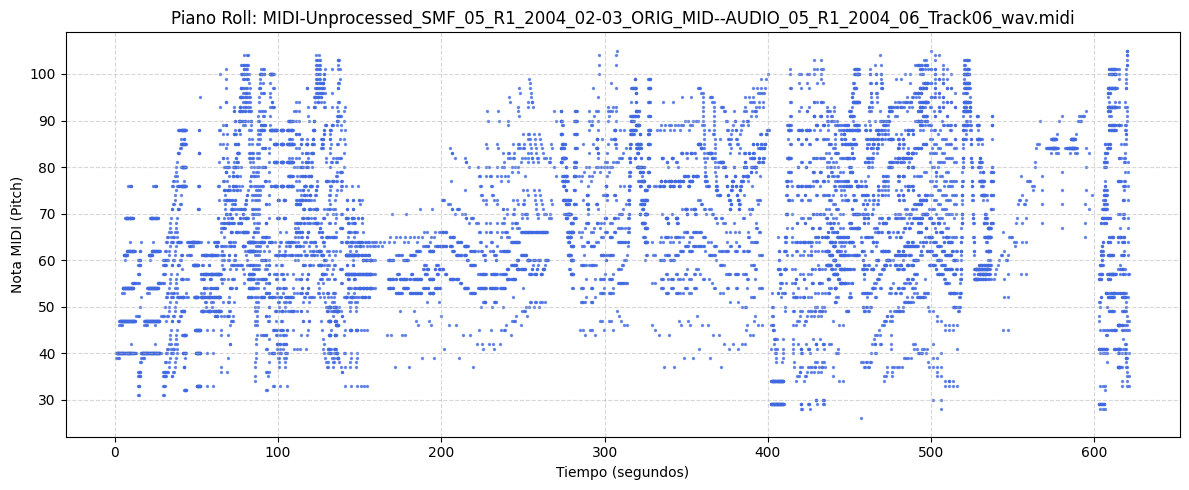

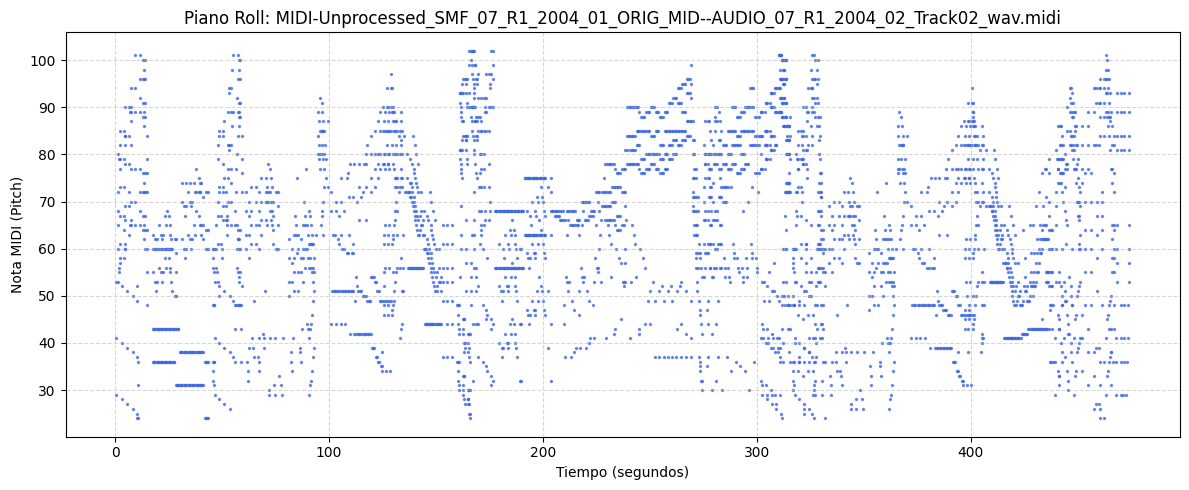

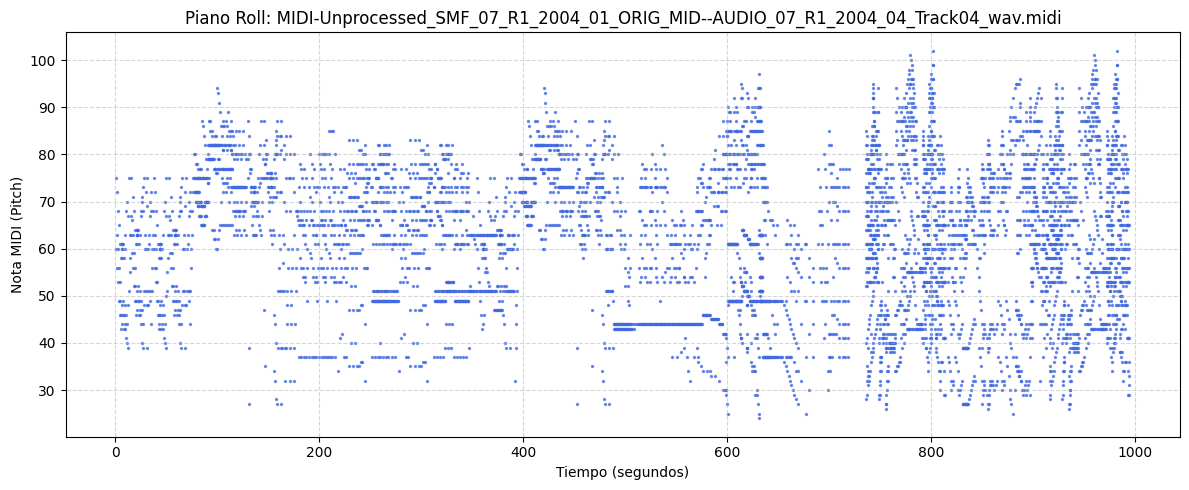

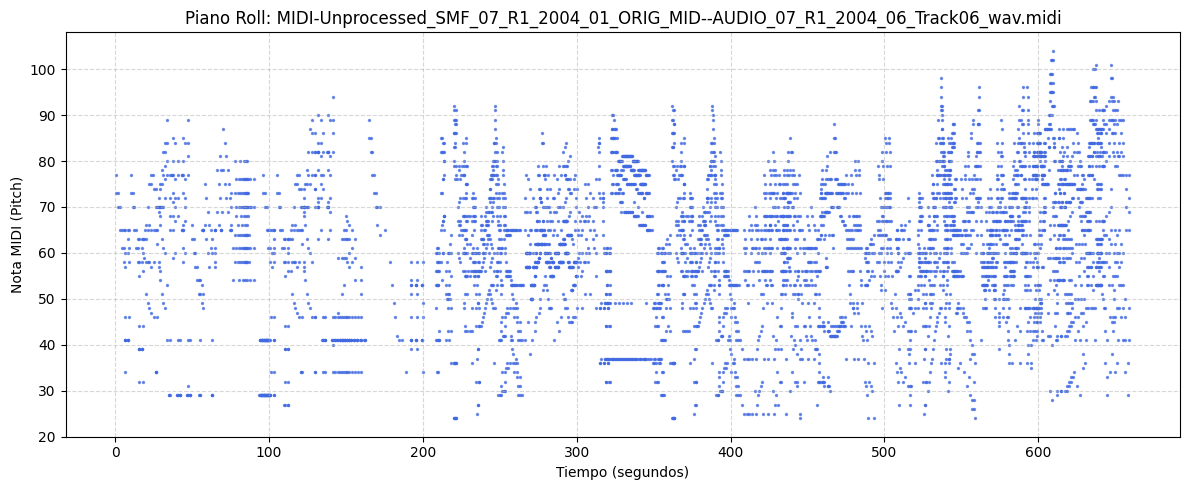

In [12]:
for i in range(0,10):
    visualizar_midi(archivos[i])